In [1]:
# Librairies
import os
import sys
import pandas as pd
import numpy as np

# Add path of HydromodPY
#sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/CORE_COMM/src')

user_path="Alexandre"
user_path="Jean-Raynald"

if user_path=="Alexandre":
    sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
elif user_path=="Jean-Raynald":
    sys.path.append('C:/DATA/codes-gitlab-public/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
else:
    print("Define a well-validated name of user")

# Modules
import watershed

In [2]:
load=False
'''
watershed_name = 'Barneville-Carteret'
x_outlet = 352300
y_outlet = 6929662
watershed_name = 'Baie-du-cotentin'
x_outlet = 399382
y_outlet = 6929848
watershed_name = 'Saint-Germain-sur-Ay'
x_outlet = 364188
y_outlet = 6913437'''
watershed_name = 'Agon-Coutainville'
x_outlet = 363669
y_outlet = 6894593
snap_dist = 100

if user_path=="Alexandre":
    root_path= "C:/Users/alexa/Dropbox/HydroModPy/_data/"
    out_path = 'C:/Users/alexa/Dropbox/HydroModPy'
elif user_path=="Jean-Raynald":
    root_path= "C:/DATA/codes-gitlab-public/HydroModPy_data/"
    out_path = "C:/DATA/results/HydroModPy"
else:
    print("Define a well-validated name of user")

dem_path = root_path + "MNT_TOPO_BATH_75m_corr.tif"
surfex_path =  root_path + 'SURFEX/Normandie_h5'
geology_path = root_path + 'GEOLOGY'
oceanic_path = root_path + 'OCEAN'
modflow_path = root_path + 'MODFLOW'
hydrology_path = root_path + 'HYDROLOGY'
BV = watershed.build(watershed_name=watershed_name, dem_path=dem_path, 
                     x_outlet=x_outlet, y_outlet=y_outlet, snap_dist=snap_dist, 
                     buff_dist=2000, out_path=out_path,surfex_path=surfex_path, 
                     geology_path = geology_path, hydrology_path=hydrology_path, oceanic_path=oceanic_path, modflow_path=modflow_path , load=load)

if load == False:
    BV.add_piezometry_data()
    BV.save_object()

Extraction des données géographiques
Extraction des données hydrologiques
Extraction des données géologiques
Extraction des données océaniques
Extraction des données climatiques
Extraction des données piézomètriques


<AxesSubplot:xlabel='Date'>

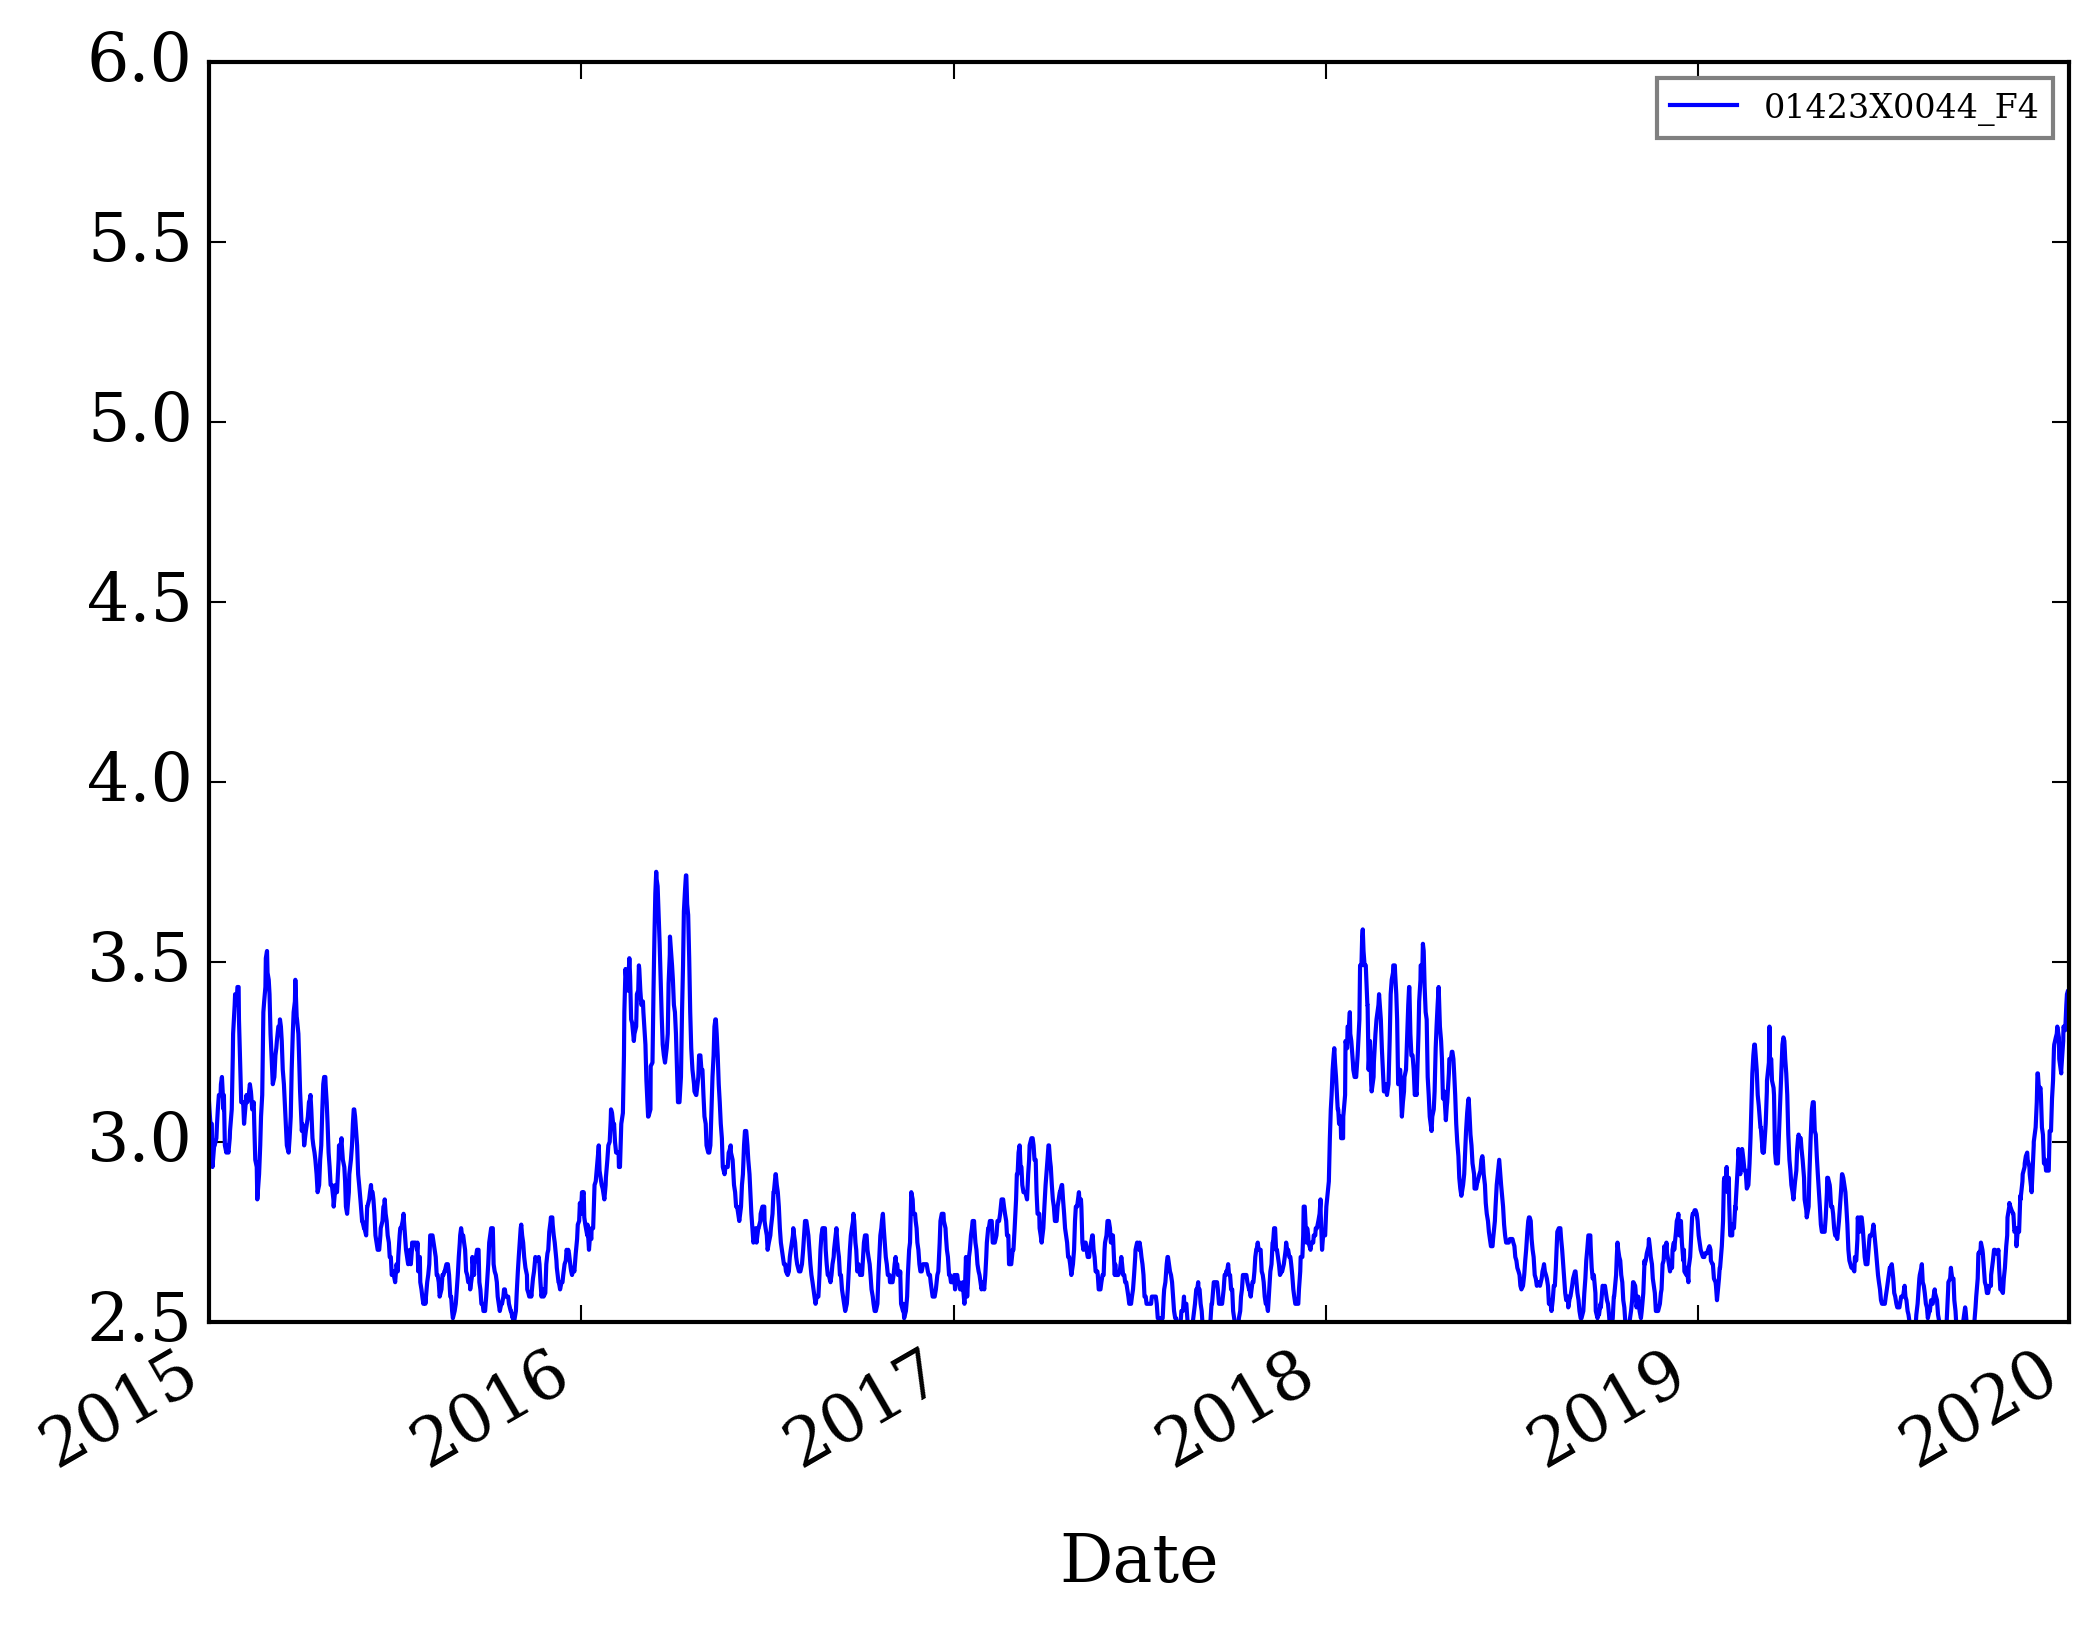

In [3]:
BV.piezometry.elevation.plot(ylim=(2.5,6), xlim=('2015','2020'))

In [4]:
climatic = BV.climatic.values['REA']['REC']['historic']['MEAN'].mean()/1000
BV.run_calibration(BV.geographic, BV.geology, climatic=climatic, type_obs='streams',
		type_mod='het', first=1, last=10000, gap=100, compt=0, watershed='name', 
		lay_number=1, thick=20, porosity=0.01, sea_level=BV.oceanic.MSL)

TypeError: 'int' object is not iterable

<Figure size 1500x1500 with 0 Axes>

In [ ]:
BV.save_object()

In [ ]:
#Transient simulation
start_date = BV.piezometry.elevation.index[0].year
end_date = BV.piezometry.elevation.index[-1].year
end_date = 2021
climatic = BV.climatic.values['REA']['REC']['historic'].loc[str(start_date):str(end_date)]['MEAN'].resample('3M').sum()/1000
name = 'test_transient'
sea_level = BV.oceanic.MSL
hyd_cond = BV.stream_het_calibration.hyd_cond
BV.run_modflow(name,climatic=climatic, lay_number=1, thick=20, bottom=None, thick_exp=1., 
		hyd_cond=hyd_cond, porosity=0.4, sea_level = sea_level, cond_decay=0.)

In [ ]:
from datetime import timedelta
import pandas as pd
import flopy.utils as fu

ax = BV.piezometry.elevation.resample('3M').mean().plot(xlim=('2005','2021'))
for i in range(0, len(BV.piezometry.y_iloc)):
    date = pd.DataFrame(BV.modflow_models['test_transient'].head_fpu.get_ts((0,BV.piezometry.y_iloc[i],BV.piezometry.x_iloc[i])), columns=['date','sim_'+BV.piezometry.codes_bss[i]])
    date['date'] = fu.totim_to_datetime(BV.modflow_models['test_transient'].head_fpu.get_ts((0,30,28))[:,0],start=climatic.index[0])
    date = date.set_index('date')
    date.plot(style='--',ax=ax)

In [ ]:
# Calibration
name = 'calibration'
k1 = 4
k2 = 2
print(k1/24/3600, k2/24/3600)
hyd_cond = np.ones(np.shape(BV.geology.geology_array))
for i in BV.geology.geology_code:
    if i == 1:
        hyd_cond[BV.geology.geology_array == 1] = k1
    if i == 2:
        hyd_cond[BV.geology.geology_array == 2] = k2
sea_level = BV.oceanic.MSL
climatic = BV.climatic.values['REA']['REC']['historic']['MEAN'].mean()/1000
BV.run_modflow(name,climatic=climatic, lay_number=1, thick=20, bottom=None, thick_exp=1., 
		hyd_cond=hyd_cond, porosity=0.01, sea_level = sea_level, cond_decay=0.)

In [ ]:
# Simulation
Mod = 'IPS1'
RCP = ['RCP2.6','RCP8.5']
Date = [2030,2050,2100]
for sce in RCP:
    print(sce)
    for d in Date:
        name = sce + '_'+str(d)
        print(d)
        climatic = BV.climatic.values['IPS1']['REC'][sce].loc[str(d-5):str(d+5)]['MEAN'].mean()/1000
        print('Recharge = '+str(climatic))
        sea_level = BV.oceanic.RMSL[sce].loc[str(d)]['median'].max()
        print('Sea level = '+str(sea_level))
        BV.run_modflow(name,climatic=climatic, lay_number=1, thick=20, bottom=None, thick_exp=1., 
		hyd_cond=hyd_cond, porosity=0.01, sea_level = sea_level, cond_decay=0.)

In [ ]:
#BV.oceanic.RMSL
import numpy as np
x = np.logspace(-4,4,100)
y = np.log10(x)**2
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x,y)
plt.xscale('log')

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(BV.modflow_models['test3'].watertable_depth)
plt.colorbar(cmap='jet_r')

In [ ]:
str(BV.oceanic.RMSL['RCP2.6']['median'].resample('M').max().index[-1])

In [ ]:
BV.piezometry.elevation.plot()

In [ ]:
BV.oceanic.display_data('RSL')

In [ ]:
BV.climatic.display_all_variables('IPS1',start='2090', end='2100')

In [ ]:
BV.climatic.display_anomaly('IPS1','REC')

In [ ]:
BV.climatic.display_intermensual_scenarios('REC')

In [ ]:
BV.climatic.display_annual_scenarios('REC')

In [ ]:
import sys
sys.path.append('C:/Users/alexa/Documents/GitHub/HydroModPy/DEV_SPEC/Alexandre/dev_modflow_hs1d')
import climatic
shp_bretagne = 'C:/Users/alexa/Dropbox/PhD/4 - Data/fr/Bretagne.shp'
shp_normandie = 'C:/Users/alexa/Dropbox/PhD/4 - Data/fr/Normandie2.shp'
surfex_path = 'D:/SURFEX/DATA/COREC_h5'
out_path = 'D:/SURFEX/'
c = climatic.extract(out_path, surfex_path, shp_normandie)


In [ ]:
import pickle

filename = 'C:/Users/alexa/Dropbox/HydroModPy/container.pkl'

class Container(object):
    def __init__(self, name):
        self.name = name
        self.widgets = []

class Widget(object):
    def __init__(self, name):
        self.name = name

c = Container('My Container')
w = Widget('My Widget')

w

c.widgets.append(w)

data = open(filename, 'wb')
pickle.dump(c, data)
data.close()

In [ ]:
dir(w)

In [ ]:
w.__class__ = 'test'

In [ ]:
c.widgets

In [ ]:
a = {}
type(a)